# Real Market Data and De-Time Feature Factory

This notebook downloads close prices, validates source coverage, and computes walk-forward De-Time features.

**Default decomposition:** `ROBUST_STL` with a 63-trading-day period, computed walk-forward where signals are backtested.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from examples.quant_trading.data import fetch_yahoo_prices, fetch_yahoo_ohlcv, data_audit_report, DEFAULT_UNIVERSES
from examples.quant_trading.features import decompose_one_series, walkforward_decompose, build_feature_table
from examples.quant_trading.signals import (
    trend_pullback_signals,
    residual_mean_reversion_signals,
    turtle_donchian_signals,
    pair_trading_weights,
    cross_sectional_rotation_weights,
    residual_stress_filter,
)
from examples.quant_trading.backtest import backtest_weights, backtest_long_short_signals, summarize_returns

DATA_CACHE = Path("examples/quant_trading/data/cache")
QUANT_METHOD = "ROBUST_STL"
QUANT_PERIOD = 63


In [2]:
tickers = ["AAPL", "MSFT", "NVDA", "005930.KS", "000660.KS", "BTC-USD", "ETH-USD"]
prices = fetch_yahoo_prices(
    tickers,
    start="2018-01-01",
    interval="1d",
    cache_dir=DATA_CACHE,
    min_observations=500,
)
prices.tail()

,AAPL,MSFT,NVDA,005930.KS,000660.KS,BTC-USD,ETH-USD
Date,,,,,,,
2026-05-18,297.839996,422.624664,222.320007,281000.0,1840000.0,76954.171875,2128.516113
2026-05-19,298.970001,416.517883,220.610001,275500.0,1745000.0,76750.906250,2109.963867
2026-05-20,302.250000,420.149994,223.470001,276000.0,1745000.0,77457.773438,2126.983398
2026-05-21,304.989990,419.089996,219.509995,299500.0,1940000.0,77539.171875,2131.410645
2026-05-22,311.364990,419.411713,217.639999,299500.0,1940000.0,76710.062500,2116.919922


In [3]:
audit = data_audit_report(prices)
audit

,ticker,first_timestamp,last_timestamp,observations,missing_ratio,min_price,max_price
0,AAPL,2018-01-01,2026-05-22,3064,0.0,33.737000,3.113650e+02
1,MSFT,2018-01-01,2026-05-22,3064,0.0,77.839211,5.386585e+02
2,NVDA,2018-01-01,2026-05-22,3064,0.0,3.150397,2.357400e+02
3,005930.KS,2018-01-01,2026-05-22,3064,0.0,31213.435547,2.995000e+05
4,000660.KS,2018-01-01,2026-05-22,3064,0.0,53071.496094,1.976000e+06
5,BTC-USD,2018-01-01,2026-05-22,3064,0.0,3236.761719,1.247525e+05
6,ETH-USD,2018-01-01,2026-05-22,3064,0.0,84.308296,4.831349e+03


## Visualization: data audit coverage

This chart exposes the real-data coverage and missingness before decomposition starts.

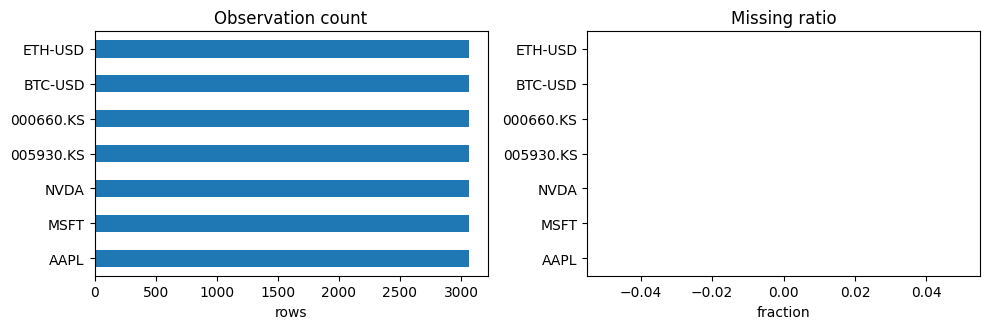

In [4]:
audit_plot = audit.set_index("ticker")[["observations", "missing_ratio"]].copy()
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
audit_plot["observations"].sort_values().plot(kind="barh", ax=axes[0], color="tab:blue", title="Observation count")
audit_plot["missing_ratio"].sort_values().plot(kind="barh", ax=axes[1], color="tab:orange", title="Missing ratio")
axes[0].set_xlabel("rows")
axes[1].set_xlabel("fraction")
for ax in axes:
    ax.set_ylabel("")
plt.tight_layout()
plt.show()


## Decompose one asset first

The output frame includes the original price, transformed price, trend, cycle/seasonal component, residual, and standardized features.

In [5]:
frame = decompose_one_series(prices["AAPL"], method=QUANT_METHOD, period=QUANT_PERIOD)
frame[["price", "trend", "season", "residual", "trend_slope", "residual_z"]].tail()

,price,trend,season,residual,trend_slope,residual_z
Date,,,,,,
2026-05-18,297.839996,5.639450,0.023087,0.034020,0.001500,1.382637
2026-05-19,298.970001,5.640976,0.030051,0.029316,0.001509,1.191345
2026-05-20,302.250000,5.642511,0.045121,0.023623,0.001518,0.983008
2026-05-21,304.989990,5.644053,0.056853,0.019372,0.001526,0.826964
2026-05-22,311.364990,5.645604,0.088072,0.007290,0.001534,0.387310


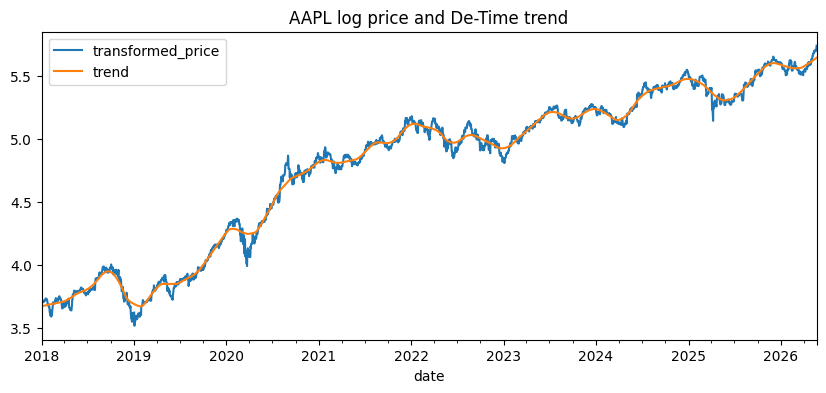

In [6]:
ax = frame[["transformed_price", "trend"]].plot(figsize=(10, 4), title="AAPL log price and De-Time trend")
ax.set_xlabel("date")
plt.show()

## Visualization: AAPL decomposition diagnostics

The diagnostic view separates trend gap, seasonal z-score, and residual z-score so the signal ingredients are visible.

## From components to strategy inputs

The feature factory is useful only if the downstream rule names what it consumes. The table below is the contract used by the strategy notebooks.

In [7]:
pd.DataFrame([
    {"component": "trend", "feature": "trend_slope", "used_by": "trend pullback, Donchian filter, rotation", "read_as": "directional bias; positive values support long exposure"},
    {"component": "season / cycle", "feature": "season_slope or season_z", "used_by": "rotation and research diagnostics", "read_as": "short-cycle tilt; useful for timing checks, not a standalone trade"},
    {"component": "residual", "feature": "residual_z", "used_by": "pullback entries and pairs spread stretch", "read_as": "temporary deviation from modeled structure"},
    {"component": "residual", "feature": "residual_abs_z", "used_by": "risk filters and regime maps", "read_as": "stress flag; high values can disable or shrink exposure"},
    {"component": "reconstruction", "feature": "reconstruction_error", "used_by": "rotation reliability penalty", "read_as": "decomposition quality warning, not alpha by itself"},
])

,component,feature,used_by,read_as
0,trend,trend_slope,"trend pullback, Donchian filter, rotation",directional bias; positive values support long...
1,season / cycle,season_slope or season_z,rotation and research diagnostics,"short-cycle tilt; useful for timing checks, no..."
2,residual,residual_z,pullback entries and pairs spread stretch,temporary deviation from modeled structure
3,residual,residual_abs_z,risk filters and regime maps,stress flag; high values can disable or shrink...
4,reconstruction,reconstruction_error,rotation reliability penalty,"decomposition quality warning, not alpha by it..."


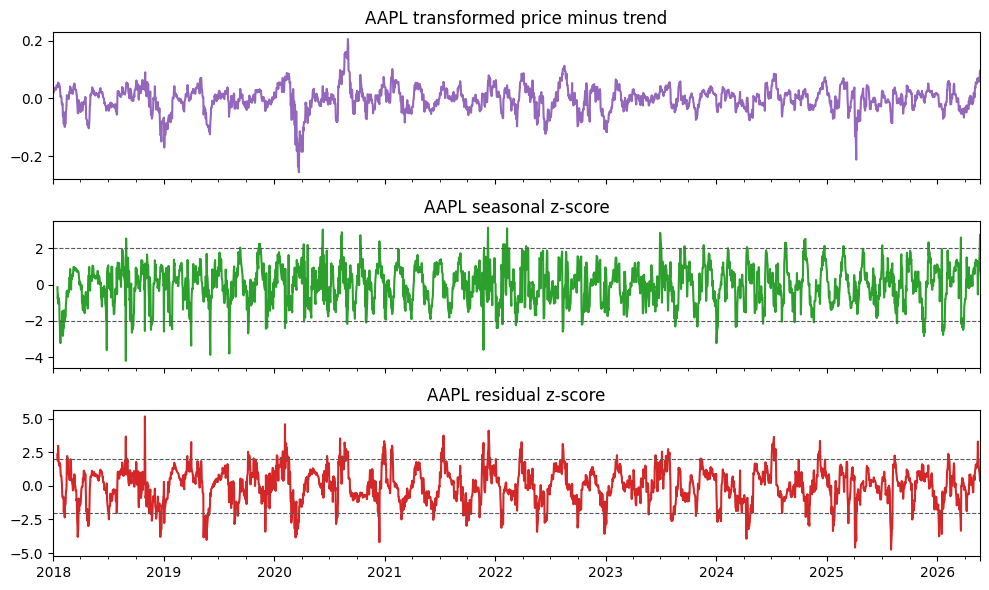

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
frame["trend_gap"].plot(ax=axes[0], color="tab:purple", title="AAPL transformed price minus trend")
frame["season_z"].plot(ax=axes[1], color="tab:green", title="AAPL seasonal z-score")
frame["residual_z"].plot(ax=axes[2], color="tab:red", title="AAPL residual z-score")
for ax in axes[1:]:
    ax.axhline(2.0, color="0.35", linestyle="--", linewidth=0.8)
    ax.axhline(-2.0, color="0.35", linestyle="--", linewidth=0.8)
for ax in axes:
    ax.set_xlabel("")
plt.tight_layout()
plt.show()


## Walk-forward feature factory

This step recomputes De-Time on rolling historical windows and keeps only the last row of each window. The resulting feature rows use only data available within each rolling window.

In [9]:
features = walkforward_decompose(
    prices[["AAPL", "MSFT", "NVDA"]],
    method=QUANT_METHOD,
    period=QUANT_PERIOD,
    train_window=252,
    step=21,
)
feature_table = build_feature_table(prices[["AAPL", "MSFT", "NVDA"]], features)
feature_table.tail()

realized_vol_20                     reconstruction_error            \
                      AAPL      MSFT      NVDA                 AAPL MSFT NVDA   
Date                                                                            
2026-05-18        0.172189  0.216533  0.379711                  0.0  0.0  0.0   
2026-05-19        0.170428  0.218846  0.374098                  0.0  0.0  0.0   
2026-05-20        0.171559  0.169817  0.329438                  0.0  0.0  0.0   
2026-05-21        0.141926  0.161623  0.337332                  0.0  0.0  0.0   
2026-05-22        0.151935  0.161602  0.340286                  0.0  0.0  0.0   

            residual                    residual_abs_z  ...     trend  \
                AAPL     MSFT      NVDA           AAPL  ...      NVDA   
Date                                                    ...             
2026-05-18  0.000256  0.00078 -0.001438       0.305554  ...  5.241956   
2026-05-19  0.000256  0.00078 -0.001438       0.305554  ...  5.241956   
2026-05-20  0.000256  0.00078 -0.001438       0.305554  ...  5.241956   
2026-05-21  0.000256  0.00078 -0.001438       0.305554  ...  5.241956   
2026-05-22  0.000256  0.00078 -0.001438       0.305554  ...  5.241956   

           trend_gap                     trend_slope                      \
                AAPL      MSFT      NVDA        AAPL      MSFT      NVDA   
Date                                                                       
2026-05-18  0.086529  0.101892  0.048582   -0.000326 -0.001566  0.000648   
2026-05-19  0.086529  0.101892  0.048582   -0.000326 -0.001566  0.000648   
2026-05-20  0.086529  0.101892  0.048582   -0.000326 -0.001566  0.000648   
2026-05-21  0.086529  0.101892  0.048582   -0.000326 -0.001566  0.000648   
2026-05-22  0.086529  0.101892  0.048582   -0.000326 -0.001566  0.000648   

           trend_strength                      
                     AAPL      MSFT      NVDA  
Date                                           
2026-05-18      -0.030100 -0.114828  0.027096  
2026-05-19      -0.030411 -0.113615  0.027503  
2026-05-20      -0.030211 -0.146418  0.031231  
2026-05-21      -0.036519 -0.153841  0.030500  
2026-05-22      -0.034113 -0.153861  0.030235  

[5 rows x 39 columns]

## Visualization: latest walk-forward features

The latest feature snapshot shows how trend strength, residual state, and reconstruction error differ across assets.

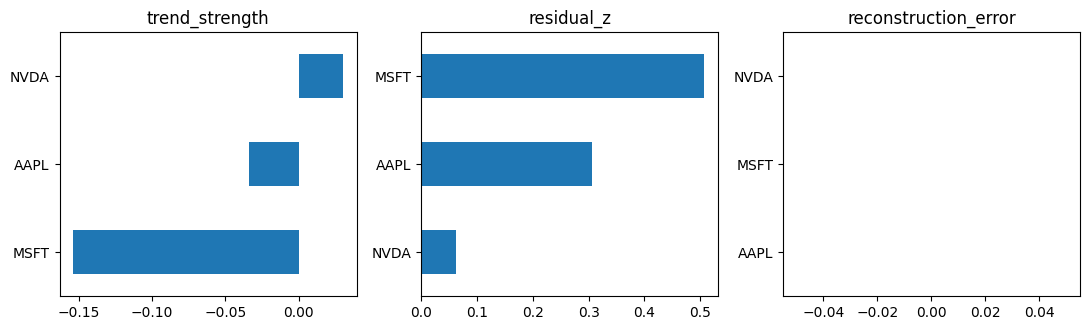

In [10]:
latest_feature_slice = feature_table.dropna(how="all").iloc[-1].unstack(0)
metric_cols = ["trend_strength", "residual_z", "reconstruction_error"]
fig, axes = plt.subplots(1, len(metric_cols), figsize=(11, 3.4))
for ax, metric in zip(axes, metric_cols):
    latest_feature_slice[metric].sort_values().plot(kind="barh", ax=ax, title=metric)
    ax.set_ylabel("")
plt.tight_layout()
plt.show()
